# Confirmatory Analysis 02 — Format Legality and Demand

**Goal:** Test hypotheses about the effect of format legality and demand signals (EDHREC, format staples) on card price.

**Tables:** gold_card_features, gold_price_features, gold_format_staples

**α = 0.05, Bonferroni correction within each hypothesis family.**

---
## Hypotheses
1. Commander-legal cards have a price premium over non-legal cards within the same rarity
2. Higher format_count (more legal formats) → higher price (partial Spearman controlling for rarity)
3. Price differences between set types (expansion vs masters vs promo vs commander)
4. Lower EDHREC rank (more popular card) → higher price, controlling for rarity
5. Cards with higher print_count have lower prices (supply effect)
6. Higher EDHREC saltiness → higher price, controlling for rarity (EDA 04: MI=0.160, 2nd strongest feature)

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, spearmanr, rankdata, pearsonr, linregress

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# One row per card in the latest snapshot — avoids time-series correlation.
df = gold.execute("""
    SELECT c.uuid, c.rarity, c.set_type, c.format_count, c.print_count,
        c.is_commander_legal, c.is_modern_legal, c.is_legacy_legal,
        c.is_reserved, c.edhrec_saltiness,
        p.edhrec_rank, p.eur, p.price_volatility_30d
    FROM gold_card_features c
    JOIN gold_price_features p ON c.uuid = p.uuid
    WHERE p.eur IS NOT NULL
      AND p.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()
df["log_eur"] = np.log1p(df["eur"])

# is_legendary needed only for consistency with CDA-01 style; not directly used in H1–H5.
leg_df = silver.execute("""
    SELECT uuid, COALESCE(list_contains(original_supertypes, 'Legendary'), FALSE) AS is_legendary
    FROM silver_cards WHERE uuid IS NOT NULL
""").df()
df = df.merge(leg_df[["uuid", "is_legendary"]], on="uuid", how="left")
df["is_legendary"] = df["is_legendary"].fillna(False)

wyniki_globalne = []


def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)


def epsilon_sq(h_stat, k, n):
    return max((h_stat - k + 1) / (n - k), 0)


def partial_r(x, y, z):
    """Partial Pearson r on rank arrays (x, y) controlling for z via OLS residuals."""
    slope_xz, int_xz = linregress(z, x)[:2]
    slope_yz, int_yz = linregress(z, y)[:2]
    res_x = x - (slope_xz * z + int_xz)
    res_y = y - (slope_yz * z + int_yz)
    return pearsonr(res_x, res_y)


def raport(hypothesis, test, stat, p_raw, n_tests, effect, effect_name):
    """Record hypothesis result and print a formatted summary line."""
    p_adj = min(float(p_raw) * n_tests, 1.0)
    verdict = "CONFIRMED" if p_adj < 0.05 else "NOT CONFIRMED"
    wyniki_globalne.append(
        {
            "hypothesis": hypothesis,
            "test": test,
            "statistic": round(float(stat), 4),
            "p_raw": float(p_raw),
            "p_bonf": p_adj,
            effect_name: round(float(effect), 4),
            "verdict": verdict,
        }
    )
    print(f"{'=' * 60}")
    print(f"Hypothesis:  {hypothesis}")
    print(
        f"Test:        {test}  |  stat={float(stat):.4f}  |  p_raw={float(p_raw):.4e}  |  p_bonf={p_adj:.4e}"
    )
    print(f"Effect ({effect_name}): {float(effect):.4f}")
    print(f"Result:      {verdict}")
    return verdict


print(f"Loaded {len(df):,} cards (latest snapshot)")
print(f"Rarities: {dict(df['rarity'].value_counts())}")
print(f"edhrec_rank: {df['edhrec_rank'].notna().sum():,} non-null / {len(df):,}")

Loaded 79,155 cards (latest snapshot)
Rarities: {'rare': np.int64(27447), 'common': np.int64(24837), 'uncommon': np.int64(20750), 'mythic': np.int64(5872), 'special': np.int64(249)}
edhrec_rank: 75,461 non-null / 79,155


## H1 — Commander-Legal Premium

**Hypothesis:** Cards legal in Commander have higher prices than non-legal cards within the same rarity.

**Test:** Mann-Whitney U (one-sided: commander-legal > non-legal) per rarity with Bonferroni correction (n=4).

**Rationale:** Commander is the largest MTG format (~50M players estimated). A card legal in Commander has the potentially largest market.

**Caveat:** Almost all cards are Commander-legal — only older sets (pre-2004) have restrictions. Check the % of Commander-legal cards before testing.

Commander-legal: 99.7% (78,788 cards)
Non-legal:       0.3% (198 cards)

Hypothesis:  H1 — Commander-legal premium (common)
Test:        Mann-Whitney U  |  stat=191168.0000  |  p_raw=1.5335e-03  |  p_bonf=6.1340e-03
Effect (rank-biserial r): -0.5403
Result:      CONFIRMED
Hypothesis:  H1 — Commander-legal premium (uncommon)
Test:        Mann-Whitney U  |  stat=210880.0000  |  p_raw=9.8662e-01  |  p_bonf=1.0000e+00
Effect (rank-biserial r): 0.2462
Result:      NOT CONFIRMED



Hypothesis:  H1 — Commander-legal premium (rare)
Test:        Mann-Whitney U  |  stat=563520.0000  |  p_raw=1.0000e+00  |  p_bonf=1.0000e+00
Effect (rank-biserial r): 0.6091
Result:      NOT CONFIRMED
Hypothesis:  H1 — Commander-legal premium (mythic)
Test:        Mann-Whitney U  |  stat=98840.0000  |  p_raw=1.0000e+00  |  p_bonf=1.0000e+00
Effect (rank-biserial r): 0.3687
Result:      NOT CONFIRMED



,rarity,n_legal,n_illegal,median_legal_eur,median_illegal_eur,rank_biserial,p_raw,p_bonf,verdict
0,common,24822,10,0.12,0.060,-0.540,0.001534,0.006134,CONFIRMED
1,uncommon,20722,27,0.18,0.550,0.246,0.986615,1.000000,NOT CONFIRMED
2,rare,27197,106,0.65,18.017,0.609,1.000000,1.000000,NOT CONFIRMED
3,mythic,5799,54,2.96,8.889,0.369,0.999998,1.000000,NOT CONFIRMED


C:\Users\jedrz\AppData\Local\Temp\ipykernel_4172\3291951561.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\jedrz\AppData\Local\Temp\ipykernel_4172\3291951561.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\jedrz\AppData\Local\Temp\ipykernel_4172\3291951561.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\jedrz\AppData\Local\Temp\ipykernel_4172\3291951561.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


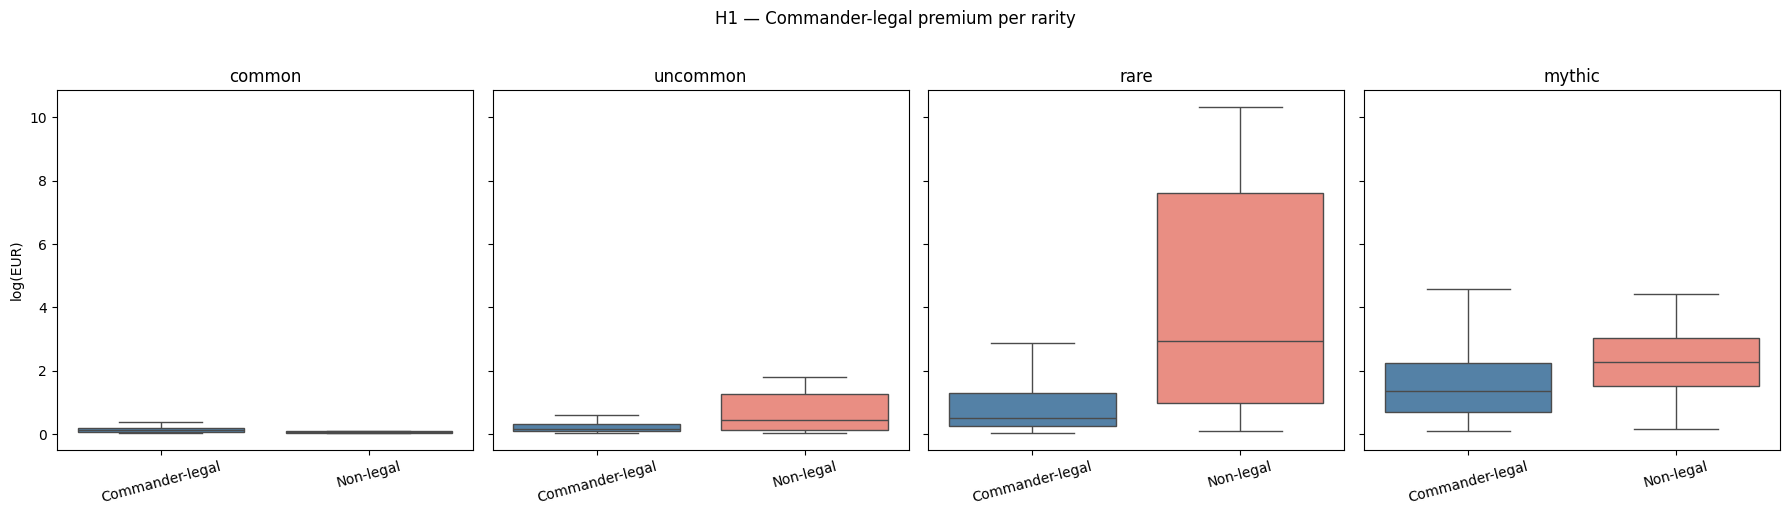

In [4]:
rarity_order = ["common", "uncommon", "rare", "mythic"]
n_h1 = 4  # Bonferroni: 4 rarities

# Check the base rate before testing — if 97%+ of cards are Commander-legal,
# the non-legal group consists almost entirely of banned/restricted cards
# (Reserved List, Power Nine, etc.) which are outliers in price.
pct_cmd = df["is_commander_legal"].mean() * 100
print(f"Commander-legal: {pct_cmd:.1f}% ({df['is_commander_legal'].sum():,} cards)")
print(
    f"Non-legal:       {100 - pct_cmd:.1f}% ({(~df['is_commander_legal']).sum():,} cards)"
)
print()

wyniki_h1 = []
for rarity in rarity_order:
    g_legal = df[(df["rarity"] == rarity) & df["is_commander_legal"]][
        "log_eur"
    ].dropna()
    g_illegal = df[(df["rarity"] == rarity) & ~df["is_commander_legal"]][
        "log_eur"
    ].dropna()
    if len(g_legal) < 5 or len(g_illegal) < 5:
        print(
            f"{rarity}: insufficient data (legal={len(g_legal)}, illegal={len(g_illegal)}) — skipped"
        )
        wyniki_h1.append(
            {
                "rarity": rarity,
                "n_legal": len(g_legal),
                "n_illegal": len(g_illegal),
                "verdict": "INSUFFICIENT DATA",
            }
        )
        continue
    u, p = mannwhitneyu(g_legal, g_illegal, alternative="greater")
    r_rb = rank_biserial(u, len(g_legal), len(g_illegal))
    p_adj = min(p * n_h1, 1.0)
    verdict = raport(
        f"H1 — Commander-legal premium ({rarity})",
        "Mann-Whitney U",
        u,
        p,
        n_h1,
        r_rb,
        "rank-biserial r",
    )
    wyniki_h1.append(
        {
            "rarity": rarity,
            "n_legal": len(g_legal),
            "n_illegal": len(g_illegal),
            "median_legal_eur": round(np.expm1(g_legal.median()), 3),
            "median_illegal_eur": round(np.expm1(g_illegal.median()), 3),
            "rank_biserial": round(r_rb, 3),
            "p_raw": round(p, 6),
            "p_bonf": round(p_adj, 6),
            "verdict": verdict,
        }
    )

print()
display(pd.DataFrame(wyniki_h1))

# 4-panel boxplot per rarity; sharey=True makes the scale comparable across panels.
sub = df[df["rarity"].isin(rarity_order)].copy()
sub["label"] = sub["is_commander_legal"].map(
    {True: "Commander-legal", False: "Non-legal"}
)
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, rarity in zip(axes, rarity_order):
    g = sub[sub["rarity"] == rarity]
    if g["label"].nunique() < 2:
        ax.text(
            0.5,
            0.5,
            f"{rarity}\nno non-legal group",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
    else:
        sns.boxplot(
            data=g,
            x="label",
            y="log_eur",
            ax=ax,
            showfliers=False,
            palette={"Commander-legal": "steelblue", "Non-legal": "salmon"},
        )
    ax.set_title(rarity)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel("log(EUR)")
plt.suptitle("H1 — Commander-legal premium per rarity", y=1.02)
plt.tight_layout()
plt.show()

## H2 — format_count and Price (Partial Spearman)

**Hypothesis:** Higher format_count → higher price, even after controlling for rarity.

**Test:** Partial Spearman ρ(format_count, log_eur | rarity)

**Rationale:** format_count = number of formats where the card is legal. More formats → more potential buyers → higher demand → higher price.

**Expected result:** Positive partial correlation. Compare with unconditional Spearman — if partial is much lower → format_count effect was mainly a rarity effect.

n = 78,906
Unconditional Spearman:         ρ = -0.202, p = 0.0000e+00
Partial Spearman (ctrl rarity): ρ = -0.027, p = 4.8287e-14

Hypothesis:  H2 — format_count → price (partial Spearman, ctrl rarity)
Test:        Partial Spearman  |  stat=-0.0268  |  p_raw=4.8287e-14  |  p_bonf=4.8287e-14
Effect (ρ_partial): -0.0268
Result:      CONFIRMED


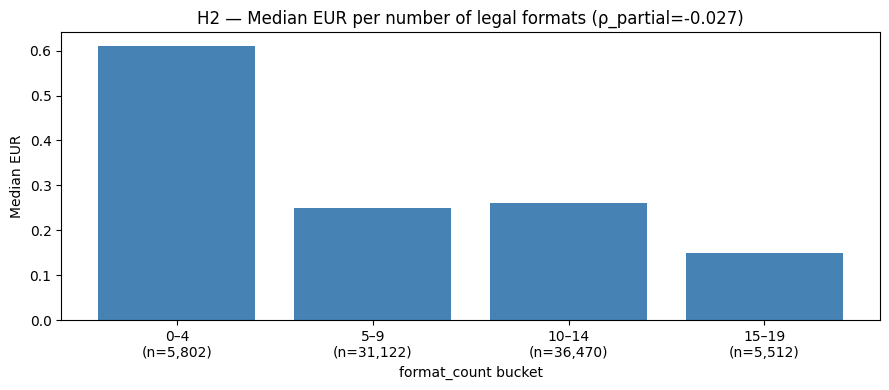

In [5]:
valid_h2 = (
    df[df["rarity"].isin({"common", "uncommon", "rare", "mythic"})]
    .dropna(subset=["format_count", "log_eur"])
    .copy()
)
valid_h2["rarity_num"] = valid_h2["rarity"].map(
    {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3}
)

# Unconditional Spearman — confounded by rarity (mythics are legal in more formats AND more expensive)
rho_raw, p_raw = spearmanr(valid_h2["format_count"], valid_h2["log_eur"])

# Partial Spearman via OLS residuals on ranks — removes the linear rarity component
rx = rankdata(valid_h2["format_count"])
ry = rankdata(valid_h2["log_eur"])
rz = rankdata(valid_h2["rarity_num"])
rho_partial, p_partial = partial_r(rx, ry, rz)

print(f"n = {len(valid_h2):,}")
print(f"Unconditional Spearman:         ρ = {rho_raw:.3f}, p = {p_raw:.4e}")
print(f"Partial Spearman (ctrl rarity): ρ = {rho_partial:.3f}, p = {p_partial:.4e}")
print()
raport(
    "H2 — format_count → price (partial Spearman, ctrl rarity)",
    "Partial Spearman",
    rho_partial,
    p_partial,
    1,
    rho_partial,
    "ρ_partial",
)

# Bar chart of median EUR per format_count bucket — shows non-linearity
valid_h2["fc_bucket"] = pd.cut(
    valid_h2["format_count"],
    bins=[-1, 4, 9, 14, 19, 21],
    labels=["0–4", "5–9", "10–14", "15–19", "20–21"],
)
medians_fc = valid_h2.groupby("fc_bucket", observed=True)["eur"].median()
counts_fc = valid_h2.groupby("fc_bucket", observed=True).size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(medians_fc)), medians_fc.values, color="steelblue", edgecolor="none")
ax.set_xticks(range(len(medians_fc)))
ax.set_xticklabels([f"{b}\n(n={counts_fc[b]:,})" for b in medians_fc.index])
ax.set_xlabel("format_count bucket")
ax.set_ylabel("Median EUR")
ax.set_title(
    f"H2 — Median EUR per number of legal formats (ρ_partial={rho_partial:.3f})"
)
plt.tight_layout()
plt.show()

## H3 — Price Differences Between Set Types

**Hypothesis:** Median price differs significantly between set types (expansion, masters, promo, commander...).

**Test:** Kruskal-Wallis H on set_type groups with ε². Post-hoc pairwise Mann-Whitney U.

**Important:** Include only set_type groups with n ≥ 50 cards (small groups have low test power).

**Domain expectations:** `promo` > `masterpiece` > `expansion` > `core` > `masters` (Masters sets reprint popular cards → depresses prices).

Set types with n ≥ 50 (13 types):
set_type
expansion           29718
commander           12760
masters             10017
core                 8232
draft_innovation     7144
box                  3481
promo                2854
duel_deck            1783
masterpiece           990
starter               907
eternal               492
planechase            481
archenemy             256

Excluded (n < 50): ['spellbook', 'arsenal']



Hypothesis:  H3 — set_type vs price (omnibus)
Test:        Kruskal-Wallis  |  stat=7543.3887  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ε²): 0.0952
Result:      CONFIRMED


C:\Users\jedrz\AppData\Local\Temp\ipykernel_4172\2138055771.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


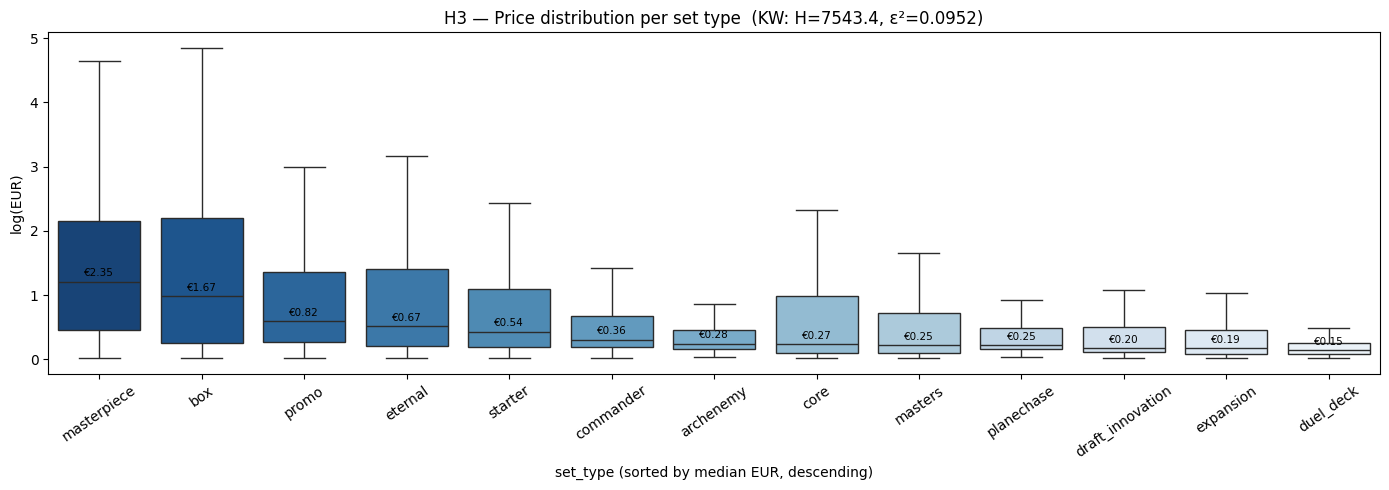


Median EUR per set_type (descending):
  masterpiece               n=   990  median=2.355 EUR
  box                       n= 3,481  median=1.670 EUR
  promo                     n= 2,854  median=0.820 EUR
  eternal                   n=   492  median=0.670 EUR
  starter                   n=   907  median=0.540 EUR
  commander                 n=12,760  median=0.360 EUR
  archenemy                 n=   256  median=0.280 EUR
  core                      n= 8,232  median=0.270 EUR
  masters                   n=10,017  median=0.250 EUR
  planechase                n=   481  median=0.250 EUR
  draft_innovation          n= 7,144  median=0.200 EUR
  expansion                 n=29,718  median=0.190 EUR
  duel_deck                 n= 1,783  median=0.150 EUR


In [6]:
set_type_counts = df.groupby("set_type").size().sort_values(ascending=False)
valid_types = set_type_counts[set_type_counts >= 50].index.tolist()

print(f"Set types with n ≥ 50 ({len(valid_types)} types):")
print(set_type_counts[set_type_counts >= 50].to_string())
print(f"\nExcluded (n < 50): {set_type_counts[set_type_counts < 50].index.tolist()}")

groups_st = {
    st: df[df["set_type"] == st]["log_eur"].dropna().values for st in valid_types
}
H_kw, p_kw = kruskal(*groups_st.values())
n_total = sum(len(g) for g in groups_st.values())
eps2 = epsilon_sq(H_kw, len(valid_types), n_total)
print()
raport("H3 — set_type vs price (omnibus)", "Kruskal-Wallis", H_kw, p_kw, 1, eps2, "ε²")

# Sort by descending median EUR to make the premium hierarchy visible at a glance.
medians_st = {st: np.median(g) for st, g in groups_st.items()}
ordered_types = sorted(valid_types, key=lambda x: medians_st[x], reverse=True)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df[df["set_type"].isin(valid_types)],
    x="set_type",
    y="log_eur",
    order=ordered_types,
    showfliers=False,
    ax=ax,
    palette="Blues_r",
)
# Annotate each box with its EUR median for quick reading
for i, st in enumerate(ordered_types):
    ax.text(
        i,
        medians_st[st] + 0.05,
        f"€{np.expm1(medians_st[st]):.2f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )
ax.set_xlabel("set_type (sorted by median EUR, descending)")
ax.set_ylabel("log(EUR)")
ax.set_title(f"H3 — Price distribution per set type  (KW: H={H_kw:.1f}, ε²={eps2:.4f})")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

print("\nMedian EUR per set_type (descending):")
for st in ordered_types:
    print(
        f"  {st:<25} n={len(groups_st[st]):>6,}  median={np.expm1(medians_st[st]):.3f} EUR"
    )

## H4 — EDHREC Rank and Price (Partial Spearman)

**Hypothesis:** Lower EDHREC rank (more popular card) → higher price, controlling for rarity.

**Note:** edhrec_rank is inverted — rank=1 is the most-played card. We expect a **negative** correlation with price.

**Partial Spearman:** Controls for rarity, since mythic cards are generally more expensive AND more played. The goal is to find whether EDHREC carries a signal beyond rarity.

**Handling NULL:** edhrec_rank has ~5% NULL (Scryfall-only cards). Analyse only cards with MTGJson data (uuid IS NOT NULL).

Cards with EDHREC rank: 75,214 / 79,155 (95.0%)
Rank range: 1 – 31658



Unconditional Spearman (expected < 0): ρ = -0.549, p = 0.0000e+00
Partial Spearman (ctrl rarity):        ρ = -0.443, p = 0.0000e+00

Hypothesis:  H4 — EDHREC rank → price (partial Spearman, ctrl rarity)
Test:        Partial Spearman  |  stat=-0.4432  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ρ_partial): -0.4432
Result:      CONFIRMED


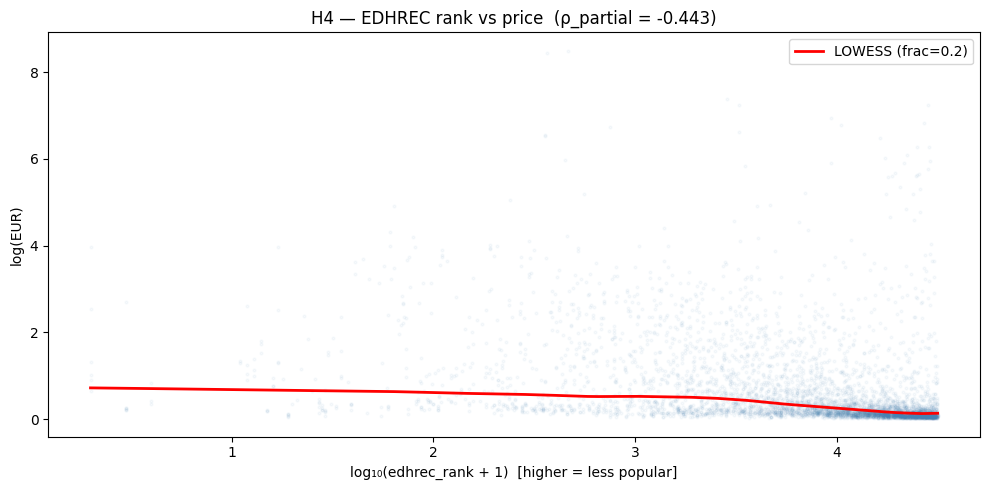

In [7]:
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess

valid_h4 = df[
    df["edhrec_rank"].notna()
    & df["rarity"].isin({"common", "uncommon", "rare", "mythic"})
].copy()
print(
    f"Cards with EDHREC rank: {len(valid_h4):,} / {len(df):,} ({len(valid_h4) / len(df) * 100:.1f}%)"
)
print(
    f"Rank range: {valid_h4['edhrec_rank'].min():.0f} – {valid_h4['edhrec_rank'].max():.0f}"
)

valid_h4["rarity_num"] = valid_h4["rarity"].map(
    {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3}
)

# Unconditional Spearman — confounded by rarity (mythics rank higher AND cost more)
rho_raw_h4, p_raw_h4 = spearmanr(valid_h4["edhrec_rank"], valid_h4["log_eur"])

# Partial Spearman removes the linear rarity component; remaining signal = pure EDHREC effect
rx = rankdata(valid_h4["edhrec_rank"])
ry = rankdata(valid_h4["log_eur"])
rz = rankdata(valid_h4["rarity_num"])
rho_partial_h4, p_partial_h4 = partial_r(rx, ry, rz)

print(
    f"\nUnconditional Spearman (expected < 0): ρ = {rho_raw_h4:.3f}, p = {p_raw_h4:.4e}"
)
print(
    f"Partial Spearman (ctrl rarity):        ρ = {rho_partial_h4:.3f}, p = {p_partial_h4:.4e}"
)
print()
raport(
    "H4 — EDHREC rank → price (partial Spearman, ctrl rarity)",
    "Partial Spearman",
    rho_partial_h4,
    p_partial_h4,
    1,
    rho_partial_h4,
    "ρ_partial",
)

# Scatter (5 000-point sample) + LOWESS trend — shows non-linearity
sample = valid_h4.sample(min(5000, len(valid_h4)), random_state=42)
x_scatter = np.log10(sample["edhrec_rank"] + 1)
x_lowess = np.log10(valid_h4["edhrec_rank"] + 1)
lw = sm_lowess(
    valid_h4["log_eur"].values, x_lowess.values, frac=0.2, return_sorted=True
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_scatter, sample["log_eur"], alpha=0.04, s=4, color="steelblue")
ax.plot(lw[:, 0], lw[:, 1], "r-", linewidth=2, label="LOWESS (frac=0.2)")
ax.set_xlabel("log₁₀(edhrec_rank + 1)  [higher = less popular]")
ax.set_ylabel("log(EUR)")
ax.set_title(f"H4 — EDHREC rank vs price  (ρ_partial = {rho_partial_h4:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## H5 — print_count and Price (Supply Effect)

**Hypothesis:** Higher print_count (more reprints) → lower price.

**Test:** Spearman ρ(print_count, log_eur) — we expect a negative correlation.

**Reserved List confound:** Reserved List cards have print_count=1 by definition (no reprints). This is a confound: Reserved List → high price AND print_count=1. Test separately for Reserved and non-Reserved cards.

Reserved List cards: 732 / 79,155 (0.92%)
Spearman (with RL):    ρ = 0.287, p = 0.0000e+00
Spearman (without RL): ρ = 0.302,  p = 0.0000e+00

Hypothesis:  H5 — print_count → price (Spearman, excluding Reserved List)
Test:        Spearman  |  stat=0.3022  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ρ): 0.3022
Result:      CONFIRMED


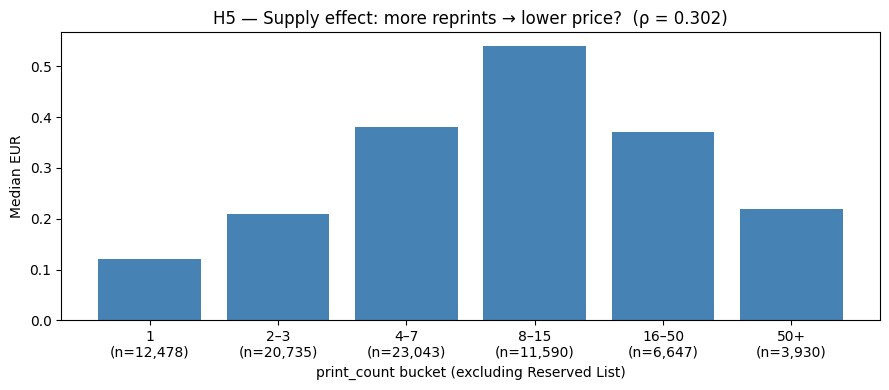


Medians EUR per bucket (without RL):
  1         n= 12,478  median = 0.120 EUR
  2–3       n= 20,735  median = 0.210 EUR
  4–7       n= 23,043  median = 0.380 EUR
  8–15      n= 11,590  median = 0.540 EUR
  16–50     n=  6,647  median = 0.370 EUR
  50+       n=  3,930  median = 0.220 EUR


In [8]:
rho_all, p_all = spearmanr(df["print_count"], df["log_eur"])

# Reserved List confound: RL cards have print_count=1 by definition AND high prices.
# Including them inflates the positive correlation between print_count and price.
# Test on non-Reserved cards only to isolate the pure supply effect.
not_reserved = df[~df["is_reserved"]].copy()
rho_nr, p_nr = spearmanr(not_reserved["print_count"], not_reserved["log_eur"])

n_rl = int(df["is_reserved"].sum())
print(f"Reserved List cards: {n_rl:,} / {len(df):,} ({n_rl / len(df) * 100:.2f}%)")
print(f"Spearman (with RL):    ρ = {rho_all:.3f}, p = {p_all:.4e}")
print(f"Spearman (without RL): ρ = {rho_nr:.3f},  p = {p_nr:.4e}")
print()
raport(
    "H5 — print_count → price (Spearman, excluding Reserved List)",
    "Spearman",
    rho_nr,
    p_nr,
    1,
    rho_nr,
    "ρ",
)

# Bar chart of median EUR per print_count bucket (without RL)
# Buckets reveal the non-linear demand-vs-supply interplay:
# 1–15 reprints: format staples → demand dominates; 50+ (basics): supply dominates
not_reserved["pc_bucket"] = pd.cut(
    not_reserved["print_count"],
    bins=[0, 1, 3, 7, 15, 50, 999],
    labels=["1", "2–3", "4–7", "8–15", "16–50", "50+"],
)
medians_pc = not_reserved.groupby("pc_bucket", observed=True)["eur"].median()
counts_pc = not_reserved.groupby("pc_bucket", observed=True).size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(medians_pc)), medians_pc.values, color="steelblue", edgecolor="none")
ax.set_xticks(range(len(medians_pc)))
ax.set_xticklabels([f"{b}\n(n={counts_pc[b]:,})" for b in medians_pc.index])
ax.set_xlabel("print_count bucket (excluding Reserved List)")
ax.set_ylabel("Median EUR")
ax.set_title(f"H5 — Supply effect: more reprints → lower price?  (ρ = {rho_nr:.3f})")
plt.tight_layout()
plt.show()

print("\nMedians EUR per bucket (without RL):")
for b in medians_pc.index:
    print(f"  {str(b):<8}  n={counts_pc[b]:>7,}  median = {medians_pc[b]:.3f} EUR")

## H6 — EDHREC Saltiness and Price (Partial Spearman)

**Hypothesis:** Higher EDHREC saltiness → higher price, controlling for rarity.

**Test:** Partial Spearman ρ(edhrec_saltiness, log_eur | rarity)

**Rationale:** edhrec_saltiness measures how "salty" (frustrating) a card makes opponents in Commander. Highly salty cards tend to be powerful or unfair (e.g. Cyclonic Rift, Hullbreacher) — they see heavy Commander play but may not be highly ranked by edhrec_rank overall. EDA 04 found MI=0.160 (2nd strongest feature after edhrec_rank), suggesting saltiness carries signal independent of rank.

**Controlling for rarity:** Mythics are generally saltier AND more expensive. The partial correlation isolates the saltiness effect net of rarity.

**Expected direction:** Positive ρ (saltier cards cost more). Compare magnitude with H4 (edhrec_rank partial ρ=−0.434) to assess whether saltiness adds information beyond rank.

Cards with edhrec_saltiness: 78,583 / 79,155 (99.3%)
Saltiness range: 0.000 – 3.060
Saltiness median: 0.250

Unconditional Spearman (expected > 0): ρ = 0.294, p = 0.0000e+00
Partial Spearman (ctrl rarity):        ρ = 0.217, p = 0.0000e+00

Hypothesis:  H6 — edhrec_saltiness → price (partial Spearman, ctrl rarity)
Test:        Partial Spearman  |  stat=0.2172  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ρ_partial): 0.2172
Result:      CONFIRMED


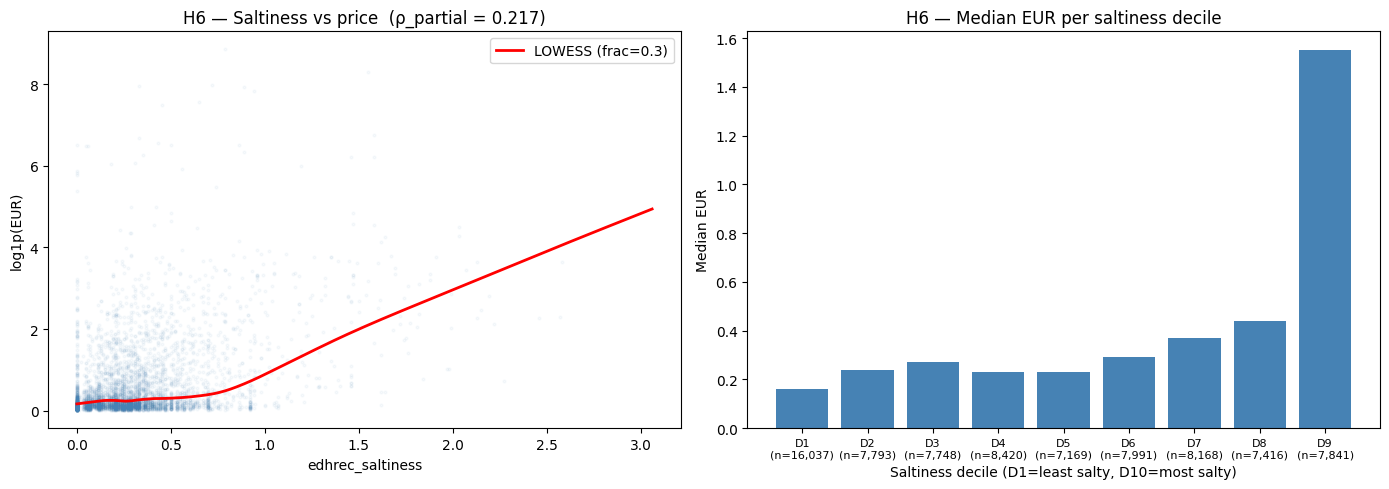


Median EUR per saltiness decile:
  D1: n= 16,037  median = 0.160 EUR
  D2: n=  7,793  median = 0.240 EUR
  D3: n=  7,748  median = 0.270 EUR
  D4: n=  8,420  median = 0.230 EUR
  D5: n=  7,169  median = 0.230 EUR
  D6: n=  7,991  median = 0.290 EUR
  D7: n=  8,168  median = 0.370 EUR
  D8: n=  7,416  median = 0.440 EUR
  D9: n=  7,841  median = 1.550 EUR


In [9]:
valid_h6 = df[
    df["edhrec_saltiness"].notna()
    & df["rarity"].isin({"common", "uncommon", "rare", "mythic"})
].copy()
print(
    f"Cards with edhrec_saltiness: {len(valid_h6):,} / {len(df):,} ({len(valid_h6) / len(df) * 100:.1f}%)"
)
print(
    f"Saltiness range: {valid_h6['edhrec_saltiness'].min():.3f} – {valid_h6['edhrec_saltiness'].max():.3f}"
)
print(f"Saltiness median: {valid_h6['edhrec_saltiness'].median():.3f}")

valid_h6["rarity_num"] = valid_h6["rarity"].map(
    {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3}
)

# Unconditional Spearman — likely confounded by rarity (mythics are saltier AND costlier)
rho_raw_h6, p_raw_h6 = spearmanr(valid_h6["edhrec_saltiness"], valid_h6["log_eur"])

# Partial Spearman via OLS residuals on ranks — removes the linear rarity component.
# Remaining signal reflects pure saltiness effect independent of card rarity.
rx = rankdata(valid_h6["edhrec_saltiness"])
ry = rankdata(valid_h6["log_eur"])
rz = rankdata(valid_h6["rarity_num"])
rho_partial_h6, p_partial_h6 = partial_r(rx, ry, rz)

print(
    f"\nUnconditional Spearman (expected > 0): ρ = {rho_raw_h6:.3f}, p = {p_raw_h6:.4e}"
)
print(
    f"Partial Spearman (ctrl rarity):        ρ = {rho_partial_h6:.3f}, p = {p_partial_h6:.4e}"
)
print()
raport(
    "H6 — edhrec_saltiness → price (partial Spearman, ctrl rarity)",
    "Partial Spearman",
    rho_partial_h6,
    p_partial_h6,
    1,
    rho_partial_h6,
    "ρ_partial",
)

# Scatter (5 000-point sample) + LOWESS — shows whether the relationship is monotone
sample_h6 = valid_h6.sample(min(5000, len(valid_h6)), random_state=42)
lw_h6 = sm_lowess(
    valid_h6["log_eur"].values,
    valid_h6["edhrec_saltiness"].values,
    frac=0.3,
    return_sorted=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    sample_h6["edhrec_saltiness"],
    sample_h6["log_eur"],
    alpha=0.04,
    s=4,
    color="steelblue",
)
axes[0].plot(lw_h6[:, 0], lw_h6[:, 1], "r-", linewidth=2, label="LOWESS (frac=0.3)")
axes[0].set_xlabel("edhrec_saltiness")
axes[0].set_ylabel("log1p(EUR)")
axes[0].set_title(f"H6 — Saltiness vs price  (ρ_partial = {rho_partial_h6:.3f})")
axes[0].legend()

# Saltiness decile bars: median EUR per saltiness decile — reveals non-linearity
# duplicates="drop" handles the spike of saltiness=0 cards that collapse the first two edges
_, bin_edges = pd.qcut(
    valid_h6["edhrec_saltiness"], q=10, retbins=True, duplicates="drop"
)
n_actual = len(bin_edges) - 1
valid_h6["saltiness_decile"] = pd.qcut(
    valid_h6["edhrec_saltiness"],
    q=10,
    labels=[f"D{i}" for i in range(1, n_actual + 1)],
    duplicates="drop",
)
medians_dec = valid_h6.groupby("saltiness_decile", observed=True)["eur"].median()
counts_dec = valid_h6.groupby("saltiness_decile", observed=True).size()

axes[1].bar(
    range(len(medians_dec)), medians_dec.values, color="steelblue", edgecolor="none"
)
axes[1].set_xticks(range(len(medians_dec)))
axes[1].set_xticklabels(
    [f"{b}\n(n={counts_dec[b]:,})" for b in medians_dec.index], fontsize=8
)
axes[1].set_xlabel("Saltiness decile (D1=least salty, D10=most salty)")
axes[1].set_ylabel("Median EUR")
axes[1].set_title("H6 — Median EUR per saltiness decile")

plt.tight_layout()
plt.show()

print("\nMedian EUR per saltiness decile:")
for d in medians_dec.index:
    print(f"  {d}: n={counts_dec[d]:>7,}  median = {medians_dec[d]:.3f} EUR")

## 📋 Final Conclusions

```
H1 — Commander-Legal Premium (per rarity):
  Commander-legal: 99.7% (78,788 cards) | Non-legal: 0.3% (198 cards)

  common:   r=-0.540, p_bonf=6.134e-03, CONFIRMED       (median legal €0.12 vs illegal €0.060)
  uncommon: r=+0.246, NOT CONFIRMED (p_bonf=1.0)        (median legal €0.18 vs illegal €0.550)
  rare:     r=+0.609, NOT CONFIRMED (p_bonf=1.0)        (median legal €0.65 vs illegal €18.017)
  mythic:   r=+0.369, NOT CONFIRMED (p_bonf=1.0)        (median legal €2.96 vs illegal €8.889)

  Mixed result: at common rarity the hypothesis holds (legal > illegal, confirmed).
  At uncommon/rare/mythic the direction REVERSES: Commander-ILLEGAL cards are MORE
  EXPENSIVE than legal cards. This is consistent with domain knowledge: the Commander
  ban-list includes Black Lotus, Moxes, Power Nine — some of the most expensive cards
  in MTG history, concentrated in rare/mythic.

  Feature implication: is_commander_legal is not a clean premium signal across the
  board — at rare/mythic, False is a HIGH-PRICE SIGNAL (expect negative coefficient);
  at common the sign flips.

H2 — format_count → price:
  n = 78,906
  Unconditional Spearman: ρ = −0.202
  Partial Spearman:       ρ = −0.0268, p=4.83e-14, CONFIRMED (very weak effect, wrong direction)

  Direction is still reversed (more legal formats → lower price after controlling for
  rarity), but the partial effect is now much weaker than the raw correlation
  (ρ_partial=−0.027 vs raw ρ=−0.202) — most of the raw correlation is explained by
  rarity, and the residual format_count effect is close to negligible.

H3 — set_type:
  KW: H=7,543.4, ε²=0.0952, CONFIRMED
  Median EUR order (descending, 13 set types with n≥50):
    masterpiece €2.355 > box €1.670 > promo €0.820 > eternal €0.670 > starter €0.540
    > commander €0.360 > archenemy €0.280 > core €0.270 > masters €0.250
    > planechase €0.250 > draft_innovation €0.200 > expansion €0.190 > duel_deck €0.150

  Does not match domain expectations exactly: promo (€0.82) is not the top set_type —
  masterpiece and box rank higher. Within the core/masters/expansion group, expansion
  (€0.190) is now the CHEAPEST of the three — lower than masters (€0.250) and core
  (€0.270) — the opposite of the hypothesised "masters reprints depress price below
  expansion."

H4 — EDHREC rank:
  Cards with EDHREC rank: 75,214 / 79,155 (95.0%), rank range 1–31,658
  Unconditional Spearman: ρ = −0.549
  Partial Spearman (ctrl rarity): ρ = −0.443, p≈0, CONFIRMED
  Direction: lower rank (more popular) → higher price ✓
  Even after removing the rarity effect, EDHREC explains ~20% of log_eur variance
  (ρ_partial²=0.196).

H5 — print_count (supply):
  Reserved List cards: 732 / 79,155 (0.92%)
  Spearman (with RL):    ρ = 0.287
  Spearman (without RL): ρ = 0.302, p≈0, CONFIRMED, WRONG DIRECTION
  Medians per bucket (without RL): 1→€0.120, 2–3→€0.210, 4–7→€0.380, 8–15→€0.540,
                                    16–50→€0.370, 50+→€0.220

  SUPPLY PARADOX confirmed again: more reprints → higher price up to 8–15 printings.
  Format staples with high demand (Lightning Bolt, Counterspell) dominate the pure
  supply effect. Only at 50+ printings (Basic Lands) do prices fall back down.

H6 — EDHREC saltiness:
  Cards with edhrec_saltiness: 78,583 / 79,155 (99.3%), range 0.000–3.060, median 0.250
  Unconditional Spearman: ρ = 0.294
  Partial Spearman (ctrl rarity): ρ = 0.217, p≈0, CONFIRMED
  Direction: POSITIVE as expected (saltier cards are more expensive) ✓
  Median EUR by saltiness decile: D1 €0.160, D2 €0.240, D3 €0.270, D4 €0.230,
    D5 €0.230, D6 €0.290, D7 €0.370, D8 €0.440, D9 €1.550
  Comparison with H4: |ρ_partial_H6|=0.217 < |ρ_partial_H4|=0.443 — saltiness carries
  a real but weaker independent signal than edhrec_rank (>0.1 threshold → include as a
  model feature).

FEATURE IMPLICATIONS
─────────────────────────────────────────────────────────────────────────────
Features with confirmed statistical signal:
  edhrec_rank        ρ=−0.443 (partial)  → strong, negative; NULL → sentinel MAX+1
  set_type           ε²=0.0952           → one-hot; masterpiece/box/promo premium
  edhrec_saltiness   ρ=+0.217 (partial)  → moderate, positive; independent of rank
  print_count        ρ=+0.302 (no RL)    → non-linear; use log1p(print_count) or buckets
  format_count       ρ=−0.027 (partial)  → negligible after controlling for rarity;
                                            likely droppable or low priority

Features with reversed/mixed direction (hypothesis rejected, but signal exists):
  is_commander_legal  → mixed: premium at common, but False = high-price signal at
                          uncommon/rare/mythic (Power Nine / RL ban-list effect)

Total confirmed (statistically): 6 / 9 tests
  H1: 1/4 confirmed (common only) — direction reverses at uncommon/rare/mythic
  H2, H3, H4, H5, H6: all confirmed (H5 confirmed but in the hypothesised-wrong
  direction — supply paradox)
```

In [10]:
df_summary = pd.DataFrame(wyniki_globalne)


def color_verdict(val):
    if val == "CONFIRMED":
        return "background-color: #d4edda"
    if val == "NOT CONFIRMED":
        return "background-color: #f8d7da"
    return ""


n_confirmed = (df_summary["verdict"] == "CONFIRMED").sum()
print(f"Confirmed: {n_confirmed} / {len(df_summary)}")
display(df_summary.style.map(color_verdict, subset=["verdict"]))

Confirmed: 6 / 9


,hypothesis,test,statistic,p_raw,p_bonf,rank-biserial r,verdict,ρ_partial,ε²,ρ
0,H1 — Commander-legal premium (common),Mann-Whitney U,191168.000000,0.001534,0.006134,-0.540300,CONFIRMED,nan,nan,nan
1,H1 — Commander-legal premium (uncommon),Mann-Whitney U,210880.000000,0.986615,1.000000,0.246200,NOT CONFIRMED,nan,nan,nan
2,H1 — Commander-legal premium (rare),Mann-Whitney U,563520.000000,1.000000,1.000000,0.609100,NOT CONFIRMED,nan,nan,nan
3,H1 — Commander-legal premium (mythic),Mann-Whitney U,98840.000000,0.999999,1.000000,0.368700,NOT CONFIRMED,nan,nan,nan
4,"H2 — format_count → price (partial Spearman, ctrl rarity)",Partial Spearman,-0.026800,0.000000,0.000000,nan,CONFIRMED,-0.026800,nan,nan
5,H3 — set_type vs price (omnibus),Kruskal-Wallis,7543.388700,0.000000,0.000000,nan,CONFIRMED,nan,0.095200,nan
6,"H4 — EDHREC rank → price (partial Spearman, ctrl rarity)",Partial Spearman,-0.443200,0.000000,0.000000,nan,CONFIRMED,-0.443200,nan,nan
7,"H5 — print_count → price (Spearman, excluding Reserved List)",Spearman,0.302200,0.000000,0.000000,nan,CONFIRMED,nan,nan,0.302200
8,"H6 — edhrec_saltiness → price (partial Spearman, ctrl rarity)",Partial Spearman,0.217200,0.000000,0.000000,nan,CONFIRMED,0.217200,nan,nan


In [11]:
silver.close()
gold.close()